In [2]:
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.coordinates import FK5
from astropy.time import Time, TimeDelta
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
import healpy as hp
import matplotlib.pyplot as plt
from astropy.coordinates import Angle
from astropy import units
from scipy.interpolate import RectBivariateSpline
from scipy import interpolate
import copy
import os
import sys
from tqdm.notebook import tqdm
#from tqdm import tqdm
import glob
import h5py
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams["font.size"] = "18"

PATH="/Users/EoR/Python_Packages/my_codes/saras3_upgrade/mock_sims/sky_models"

path_ms1 = '/Users/EoR/Python_Packages/my_codes/saras3'
path_ms2 = '/Users/EoR/Python_Packages/my_codes/saras3/utils'
sys.path.append(path_ms1)
sys.path.append(path_ms2)
from misc import *

import ms_fit_joint as ms

import scipy.io

In [3]:
inflection    = 'all' #options: 'no', '1', 'all'

if inflection=='no':
    from ms_fit_joint import *
    fitting_function = ms_fit
else:
    from ms_fit_joint_inf import *
    fitting_function = ms_fit_inf

In [4]:
domain = 'log_log'
LOWF   = 45
HGHF   = 90
order  = 10

In [5]:
file_path = '/Users/EoR/Python_Packages/my_codes/saras3_upgrade/mock_sims/dghalli'
filename1 = 'monopole_PRATUSHpaper.h5'
filename2 = 'nonparallel_processing.h5'

In [6]:
f1 = h5py.File(os.path.join(file_path,filename1), 'r')
f2 = h5py.File(os.path.join(file_path,filename2), 'r')

In [7]:
def gen_thermal_noise(Tsys, beta, tau):
    np.random.seed(1)
    Trms = Tsys/np.sqrt(beta*tau)
    thermal_noise = np.random.normal(0,Trms,len(Tsys))
    return thermal_noise

In [8]:
f1.keys(), f2.keys()

(<KeysViewHDF5 ['T_A', 'T_A_only_beam', 'ancillary_prod', 'index_map']>,
 <KeysViewHDF5 ['T_A', 'T_A_only_beam', 'ancillary_prod', 'index_map']>)

# Difference the two files

In [9]:
diff = f1['T_A'][()] - f2['T_A'][()]

ValueError: operands could not be broadcast together with shapes (100,164) (20,72) 

In [38]:
print(np.sum(diff))

0.0


# Average spectra and fit

In [11]:
T_bws_te1        = f1['T_A_only_beam']
#T_bws_te2        = f2['T_A_only_beam']
LST1, freq_full = f1['index_map']['LST'][()], f1['index_map']['frequency'][()]
#te1              = f1['ancillary_prod']['ref_eff'][()]

data21   = scipy.io.loadmat(os.path.join(path_ms1, 'atlas/Data_18March_wMFP.mat'))
data21   = data21['Data2']/1e3 
fr       = np.loadtxt(os.path.join(path_ms1,'atlas/freq_saras.txt')) #Frequency in MHz
signal   = interpolate.interp1d(fr, data21)

In [12]:
avg_spectra_te1       = np.mean(T_bws_te1, axis=0)

T21                  = signal(freq_full)[100] #One of the vanilla models

#tau_selected = 1000*24*3600 #100 days
#avg_spectra_te1 += gen_thermal_noise(avg_spectra_te1, 1e6*np.median(np.diff(freq_full)), tau_selected)

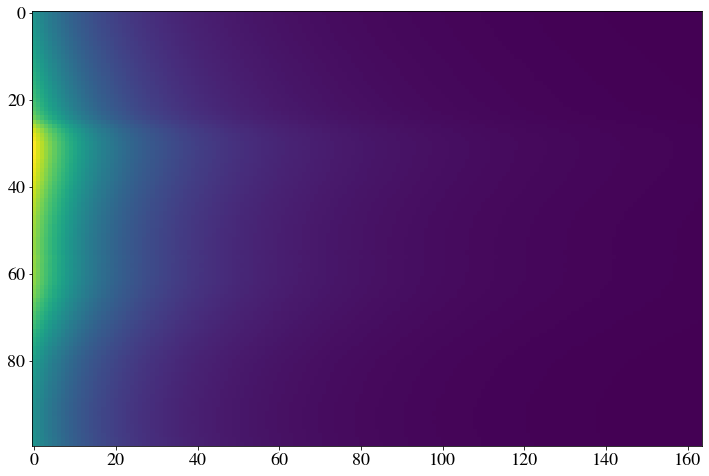

In [13]:
plt.figure(figsize=(12,8))
plt.imshow(T_bws_te1[()], aspect='auto')
plt.show()

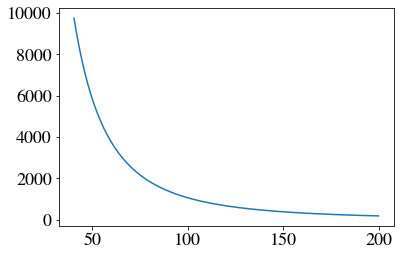

In [15]:
plt.plot(freq_full, avg_spectra_te1)

np.savetxt("PRATUSH_gmoss", np.column_stack((freq_full,avg_spectra_te1)))

In [ ]:
param_noj = {'domain':domain, 'xmin':LOWF, 'xmax':HGHF, 'rescale':True,\
         'norder':order, 'error':np.ones(len(avg_spectra_te1)), \
         'additive':False, 'op_file':False, 'op_name':False,\
         'niter':1, 'smooth':False, 'basin_iter_loops':10, 'xtol':1e-10, 'ftol':1e-10,\
         'temp':1e-5, 'stepsize':1e-5}

In [ ]:
p, x, imin, imax, fit, res, e = fitting_function(freq_full, avg_spectra_te1, **param_noj)
#Add the fit parameters into object
fits_dict = get_dict(*(p, x, imin, imax, fit, res, e, param_noj, 'no_inflection'))

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(fits_dict['res'], lw=3.0)
plt.show()